<h3><center><a href="https://www.quantumcomputing.no/event/autumn-school/">Gemini Center on Quantum Computing: Autumn School</a></center></h3>

<h1><center>Hands-on session: Quantum computing and quantum algorithms</center></h1>

## Overview

This notebook has two problems: (1) **Quantum simulation (time evolution)** which we covered in lecture and (2) a heuristic quantum algorithm for combinatorial optimization known as the **Quantum approximate optimization algorithm (QAOA)** which we did not cover in lecture.

**Time evolution** refers to (computationally) solving for the dynamics of a quantum system given an initial state and Hamiltonian. From the Schrodinger equation ($\hbar = 1$) $ \dot{\psi} = - i H \psi ,$ we can immediately write down the solution $ \psi(t) = \psi(0) \exp(-i H t)$ (for time-independent $H$). But how do you actually evaluate $\exp(-i H t)$? As this is a central question many techniques and approximations have been developed. You will implement one important and widely applicable approximation known as Trotterization (or the Trotter formula) to do this.

The **QAOA** gives an approximate solution to a (classical) optimization problem by mapping the problem to a Hamiltonian, then doing something that looks like Trotterization! You'll apply the QAOA to a commonly considered problem known as MaxCut (defined below).

## Setup

Install packages here. You are free to use any quantum information software package like [Cirq](https://quantumai.google/cirq), [Qiskit](https://qiskit.org/), or [QuTiP](https://qutip.org/). For the exact numerics, use NumPy and SciPy.

In [36]:
# Your code here!
import numpy as np
import scipy
import cirq
import functools
import matplotlib.pyplot as plt
import tqdm

## (1) Quantum simulation

We will consider the one-dimensional transverse-field Ising model (TFIM) on $n$ sites (qubits) with periodic boundary conditions

$$ H = J \sum_{i = 1}^{n} Z_i Z_{i + 1} - \Gamma \sum_{i = 1}^{n} X_i .$$

Here $X$ and $Z$ are Pauli operators which in the computational basis have matrices

$$ X = \left[ \begin{matrix} 0 & 1 \\ 1 & 0 \end{matrix} \right], \qquad Z = \left[ \begin{matrix} 1 & 0 \\ 0 & -1 \end{matrix} \right] . $$

Subscripts refer to the sites (qubits) the Pauli acts on, and products are tensor products. So, for example, $Z_1 Z_2 \equiv Z_1 \otimes Z_2 \equiv Z \otimes Z \otimes I$ with $n = 3$.

### Exact calculations

Before we start with approximations, let's do some classical brute-force, exact (unscalable) calculations.

#### (1.1) A function for the TFIM Hamiltonian

> Write a function to return the TFIM Hamiltonian $H$ as a NumPy array for a given $n$, $J$, and $\Gamma$.

In [31]:
def get_tfim_hamiltonian(
    nqubits: int, 
    coupling: float = 1, 
    gamma: float = 0.25,
) -> np.ndarray:
    
    qubits = cirq.LineQubit.range(nqubits)
    
    H = coupling*sum([cirq.Z.on(qubits[i]) * cirq.Z.on(qubits[(i+1) % nqubits]) for i in range(nqubits)])
    H -= gamma*sum([cirq.X.on(qubits[i]) for i in range(nqubits)])
    return H.matrix()

*Note: The Hamiltonian is sparse and can be more compactly represented with objects in [`scipy.sparse`](https://docs.scipy.org/doc/scipy/reference/sparse.html). Here we just use (dense) NumPy arrays for simplicity with the small ($n = 10$) problem size.*

> For the remaining problems, use the TFIM Hamiltonian $H$ with $n = 10$, $J = 1$, and $\Gamma = 0.25$.


#### (1.2) Exact time evolution to compute magnetization

> Compute and plot the magnetization $\langle Z_j \rangle (t) =  \langle \psi(t) | Z_j | \psi(t) \rangle$ for each site (qubit) $j = 1, ..., 10$ and each time $t$ in `np.linspace(0, 50, 100)`.
>
> - Here, $|\psi(t)\rangle = \exp(-i H t) |\psi(0)\rangle$ 
> - Use $|\psi(0)\rangle = |0000100000\rangle$ for the initial state. (All spins down except for one spin up in the middle.)
>
> For plotting, use [`matplotlib.pyplot.imshow`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.imshow.html) or [`matplotlib.pyplot.pcolormesh`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.pcolormesh.html) or similar.

In [34]:
nqubits=10
J=1
gamma = 0.25

qubits = cirq.LineQubit.range(nqubits)
psi_0 = [cirq.KET_ZERO.state_vector() for _ in range(nqubits)]
psi_0[nqubits//2 -1] = cirq.KET_ONE.state_vector()

psi_0 = functools.reduce(np.kron, psi_0)
H = get_tfim_hamiltonian(n, J, gamma)
#print(H)
Z_tj= np.ndarray((100, nqubits))

for i,t in tqdm(enumerate(np.linspace(0, 50, 100))):
    for j in range(nqubits):
        psi_t = scipy.linalg.expm(-1j * H * t)@psi_0
        Z_j = cirq.Z.on(qubits[j]).matrix(qubits)
        Z_tj[i,j] = np.real_if_close(psi_t.T.conj()@Z_j@psi_t)

[[10.  +0.j -0.25+0.j -0.25+0.j ...  0.  +0.j  0.  +0.j  0.  +0.j]
 [-0.25+0.j  6.  +0.j  0.  +0.j ...  0.  +0.j  0.  +0.j  0.  +0.j]
 [-0.25+0.j  0.  +0.j  6.  +0.j ...  0.  +0.j  0.  +0.j  0.  +0.j]
 ...
 [ 0.  +0.j  0.  +0.j  0.  +0.j ...  6.  +0.j  0.  +0.j -0.25+0.j]
 [ 0.  +0.j  0.  +0.j  0.  +0.j ...  0.  +0.j  6.  +0.j -0.25+0.j]
 [ 0.  +0.j  0.  +0.j  0.  +0.j ... -0.25+0.j -0.25+0.j 10.  +0.j]]


KeyboardInterrupt: 

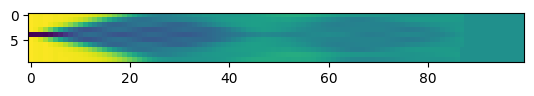

In [56]:
plt.imshow(Z_tj.T)
plt.show()

### Trotterized time evolution

Consider a Hamiltonian $H = H_A + H_B$. If $[H_A, H_B] = 0$ (square brackets denote commutation), exponentiation is very simple: $\exp(-i H t) = \exp(-i H_A t) \exp(-i H_B t)$.

Of course $[H_A, H_B] \neq 0$ in general. The [first order (Lie-) Trotter (-Suzuki) formula](https://simons.berkeley.edu/sites/default/files/docs/15639/trottererrortheorysimons.pdf) says that, if $||H_A||, ||H_B|| \le 1$,

$$ \exp (- i (H_A + H_B) t) = \exp(-i H_A t) \exp(-i H_B t) + O(|| [H_A, H_B] || t^2) .$$

For the TFIM we can split our Hamiltonian into two mutually commuting groups, namely $H_Z := J \sum_{i = 1}^{n} Z_i Z_{i + 1}$ and $H_X := - \Gamma \sum_{i = 1}^{n} X_i$, and apply this formula with $H = H_Z + H_X$.



#### (1.3) A function for 1st order Trotter

> Write a function to input time $t$ and return the (quantum circuit) operations for the first-order Trotter formula with the TFIM. Use the same $n$, $J$, and $\Gamma$ as above.

In [40]:
coupling = 1

In [41]:
def trotter_step(time: float) -> cirq.OP_TREE:
    yield [cirq.ZZ(qubits[i], qubits[(i+1)%nqubits]) ** (coupling * time / np.pi) for i in range(nqubits)]
    yield [cirq.X(qubits[i]) ** (-gamma * time * 2/np.pi) for i in range(nqubits)]

In [51]:
circuit = cirq.Circuit(
    cirq.X(qubits[nqubits // 2 -1]),
    trotter_step(time=0.5),
    cirq.measure(qubits, key="z")
)

In [55]:
cirq.Simulator().run(circuit, repetitions = 1024)

z=00000000000000000000000010000000000000000000000000000000000000000000000000000000000000000100000000000000000000000000001000000000001000000000000000000000000000001000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000010000000000000000000001000000000000000000000000000000000000000000000010000001000000000000000000000000000000000000000000000100000000000000000000000000000000000000000000000000000000000000000000000000000000000001000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000010000000000000000000010000000001000000000100000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000100000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000010000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000010000000000000000000000000000000000000000

#### (1.4) Simulation to compute the magnetization per qubit

> Simulate your circuit using $10^4$ shots (samples) to compute the magnetization per qubit using the same parameters as above, and plot the result.

In [ ]:
# Your code here!

#### (1.5) Increasing the number of Trotter steps

You should see that the previous result is poor! (Decent for the first few time steps, but very innacurate after.) This can be improved by implementing a number $r$ of Trotter steps, essentially repeating the above circuit $r$ times where each Trotter step is done for time $t / r$. Specifically, the first-order Trotter formula with $r$ steps says that

$$ \exp (- i (H_A + H_B) t) = [\exp(-i H_A t / r) \exp(-i H_B t / r)]^r + O\left( \frac{|| [H_A, H_B] || t^2}{r}\right) .$$

This is now nice because the error goes to zero as $r \rightarrow \infty$, and we can decrease the error by using more steps. The cost, of course, is more gates in the circuit.

> Do the same simulation as (1.4) but now using $r = 10, 20,$ and $40$ Trotter steps. Plot the results and compare to the exact solution.

In [ ]:
# Your code here!

### Further reading

- We looked at the first-order Trotter formula, but there are higher orders: Read more [here](https://simons.berkeley.edu/sites/default/files/docs/15639/trottererrortheorysimons.pdf).
- You may be interested in [imaginary time evolution](https://www.nature.com/articles/s41534-021-00409-y), another technique to find the ground state of a time-independent Hamiltonian.
- Want to simulate a time-dependent Hamiltonian? You may want to know about the [quantum adiabatic theorem](http://www.cs.umd.edu/~amchilds/teaching/w08/l18.pdf).

## (2) QAOA with MaxCut

The quantum approximate optimization algorithm (QAOA) is a variational algorithm which inputs a classical cost function $f : \mathbb{Z}_2^n \rightarrow \mathbb{R}$ and outputs the approximate argmax $z_1^*, ..., z_n^*$ (where we use the maximum without loss of generality). The QAOA procedure is to

1. Quantize the cost function by mapping bits (spins) $z_i$ to Pauli $Z_i$ to obtain a diagonal Hamiltonian.
2. Use a quantum computer to prepare a variational ansatz

$$ |\gamma_1, \beta_1, ..., \gamma_p, \beta_p \rangle := \prod_{k = 1}^{p} e^{-i \beta_k \sum_{j = 1}^{n} X_i } e^{-i \gamma_k f(Z_1, ..., Z_n)} H^{\otimes n} |0 ^{\otimes n} \rangle
$$

3. Find the best parameters $\gamma_1, \beta_1, ..., \gamma_p, \beta_p$ by maximizing the energy of this state.
4. Sample bitstrings from this state and return the bitstring with the highest energy.

The intuition is that sampling from the initial state $H^{\otimes n} |0 ^{\otimes n}\rangle$ produces bitstrings uniformly at random. Subsequently "driving" this state with the diagonal operator $e^{-i \gamma_k f(Z_1, ..., Z_n)}$ uses information about the cost function $f$ to apply phases to certain states, then "mixing" these states with the non-diagonal operator $e^{-i \beta_k \sum_{j = 1}^{n} X_i }$ allows these phased amplitudes to constructively and destructively interfere. You hope that optimizing the parameters $\gamma_1, \beta_1, ..., \gamma_p, \beta_p$ is easier than the initial optimization problem $f(z_1, ..., z_n)$. Some results for constant depth $p = O(1)$ and log depth $p = O(\log n)$ QAOA are known, but in general the behavior is not yet fully understood and the algorithm is heuristic.

In this problem you will apply QAOA to a common example problem: MaxCut.

### (2.1) The MaxCut objective function

In MaxCut you are given a graph $G = (V, E)$ with $|V| = n$ nodes. You are to assign each node $z_1, ..., z_n$ to one of two classes, call them $-1$ and $+1$. Note that there are $2^n$ assignments. The goal is to maximize the number of edges between the two classes: for each edge $e = (i, j)$, you get $1$ point if $z_i$ and $z_j$ are different, and you get $0$ points if $z_i$ and $z_j$ are the same. Mathematically this can be expressed as

$$ c(z_i, z_j) = (1 - z_i z_j) / 2 . $$

The full objective function is then this quantity summed over all edges,

$$ f(z_1, ..., z_n) = \frac{1}{2} \sum_{(i, j) \in E} (1 - z_i z_j) . $$

Note that you can insert a $w_{ij}$ in this summation for MaxCut with weighted graphs. Here we only consider unweighted graphs.

> Write a function `compute_objective` to return the value of the MaxCut objective function for a given assignment $z_1, ..., z_n$ for the provided graph.

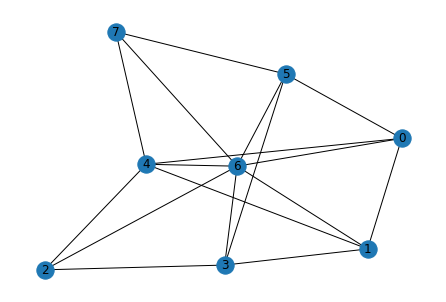

In [ ]:
"""Provided graph for the MaxCut problem.

This cell assumes you have NetworkX (https://networkx.org/) installed 
(pip install networkx) and have run `import networkx as nx`!
"""

n = 8
graph = nx.erdos_renyi_graph(n=n, p=0.5, seed=1, directed=False)
nx.draw(graph, with_labels=True)

In [ ]:
from typing import List


def compute_objective(assignment: List[int]) -> float:
    pass  # Your code here!

> As a simple test, check that your function returns the same value for the all $-1$ assignment and the all $+1$ assignment.

In [ ]:
"""This assert statement should pass (return True), assuming you kept the same
function name `compute_objective` and kept `n` as the number of nodes. 

If it doesn't pass, you have a bug!
"""
assert compute_objective([-1] * n) == compute_objective([1] * n)

> Try a few assignments - whoever gets the highest objective function value wins!

In [ ]:
# Your code here!

> Iterate over all $2^n$ assignments and find the best one. *Hint: See [`itertools.product`](https://docs.python.org/3/library/itertools.html#itertools.product)*.

In [ ]:
# Your code here!

### (2.2) The QAOA ansatz

Now that we know the highest objective function value and corresponding assignment(s) (there may be degeneracy), let's turn the the QAOA.

> Write a function to return the QAOA ansatz at any depth ($p = 1, 2, 3, ...$) for the provided graph and for a given set of angles. The signature of this function should be
>
> ```python
def get_qaoa_circuit(graph: nx.Graph, angles: np.ndarray) -> cirq.Circuit:
```
> (or whatever package you used if not Cirq). The number of layers is determined by the number of angles provided.

In [ ]:
def get_qaoa_circuit(graph: nx.Graph, angles: np.ndarray) -> cirq.Circuit:
    pass  # Your code here!

### (2.3) Evaluating the energy

> Write a function to estimate the energy obtained by the angles in the QAOA via sampling from the QAOA circuit. The signature of this function should be
> ```python
def estimate_energy(graph: nx.Graph, angles: np.ndarray, nshots: int = 10_000) -> float:
```
> As in the above signature, use a default value of $10^4$ shots.
> *Hint: Use your function `compute_objective` from (2.1) to compute the objective function value above, and average this over all sampled bitstrings. Note that sampled bitstrings will be in $\{0, 1\}^n$.*

In [ ]:
def estimate_energy(graph: nx.Graph, angles: np.ndarray, nshots: int = 10_000) -> float:
    pass  # Your code here!

### (2.4) Optimizing the angles

Now that we have a function to estimate the energy as a function of the angles, we can optimize the angles.

> Perform a grid search over $\gamma, \beta$ in $p = 1$ QAOA. Use a $20 \times 20$ grid (or $15 \times 15$ if that's too slow). Plot the energy landscape (with, e.g., [`matplotlib.pyplot.pcolormesh`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.pcolormesh.html)) and find the $\gamma, \beta$ which yield the highest energy.

In [ ]:
# Your code here!

### (2.5) Sampling assignments at the best angles

For MaxCut we care about the assignment not just the energy, and typically the final step is to sample a bunch of assignments (bitstrings) at the best angles you found, then take the best of the best!

> Using the best $\gamma, \beta$ you found via grid search, sample $10^4$ bitstrings from the $p = 1$ QAOA circuit at these angles. Evaluate the energy of each one and select the assignment with the highest energy. How does your energy and assignment compare to the brute force solution?

In [ ]:
# Your code here!

### (2.6) Increasing the number of layers

You should have found above that your can find the maximum cut with $p = 1$ QAOA. For larger/harder problems this may not be the case, and you may need to use $p > 1$ layers (also called rounds) of QAOA.

> Use a dense random graph with $n \ge 12$ nodes. Define the approximation ratio $r(p)$ to be the best energy achieved by the QAOA with $p$ layers relative to the best energy (found exactly). Evaluate $r(p)$ for $p = 1, 2, 3$ and demonstrate that $r(3) \ge r(2) \ge r(1)$. What $p$ do you need to use to get $r(p) \ge 0.99$?

In [ ]:
# Your code here!

### Further reading

- Want to know more about variational algorithms, their strengths and weaknesses, and open problems? Check out out this [review of variational quantum algorithms](https://arxiv.org/abs/2012.09265).
- You may want to read the [original QAOA paper](https://arxiv.org/abs/1411.4028) from 2014 and even check out this [video](https://drive.google.com/file/d/13nz9uFa6H0TUPYlTra_8fuyNTIURHh1Y/preview) of Edward Farhi talking about the algorithm, including a funny story of how he and his coauthors came up with it.
- In these problems we only had a few variational parameters, but optimizing many of them becomes a challenge. One way to do this optimization is via gradient descent where gradients are computed via the ["parameter shift rule"](https://pennylane.ai/qml/glossary/parameter_shift.html).